In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 1: Setup & Environment

print("--- Initializing Driver Sensitivity Analysis (Square One) ---")
%pip install pandas geopandas rasterio shapely fiona pyproj xarray netCDF4 matplotlib seaborn -q

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
%cd "/content/drive/MyDrive/IndiaProject_Colab"

# Load Project Functions
%run 00_Functions_and_Setup.ipynb

# Load Master Data & Shapefile
if 'yld' not in locals():
    yld = pd.read_csv("data/processed/icrisat_yield_area_irrig_4crops_long_2000_2017.csv")
if 'districts_gdf' not in locals():
    districts_gdf = gpd.read_file("data/processed/districts_joined.gpkg")
    state_boundaries_gdf = districts_gdf.dissolve(by='state_shp').reset_index()

# Define Core Production Filter
def get_cropping_fraction(crop_name):
    crop_data = yld[(yld['crop'] == crop_name) & (yld['yield_kg_per_ha'] > 0)].copy()
    avg_area = crop_data.groupby('Dist Code')['total_area_1000ha'].mean().reset_index()
    avg_area['harvested_ha'] = avg_area['total_area_1000ha'] * 1000

    dist_proj = districts_gdf.to_crs(epsg=6933)
    dist_areas = dist_proj[['Dist Code', 'geometry']].copy()
    dist_areas['district_total_ha'] = dist_proj.geometry.area / 10000

    merged = avg_area.merge(dist_areas, on='Dist Code', how='inner')
    merged['cropping_fraction'] = merged['harvested_ha'] / merged['district_total_ha']
    merged['cropping_fraction'] = merged['cropping_fraction'].clip(upper=1.0)
    return merged[['Dist Code', 'cropping_fraction']]

print("[✓] Environment Ready.")

--- Initializing Driver Sensitivity Analysis (Square One) ---
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 38.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 35.8 MB/s eta 0:00:00
Mounted at /content/drive
/content/drive/MyDrive/IndiaProject_Colab
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 34.2 MB/s eta 0:00:00
[✓] Environment Ready.


--- Fitting Base Model: Linear Soil Moisture Sensitivities ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


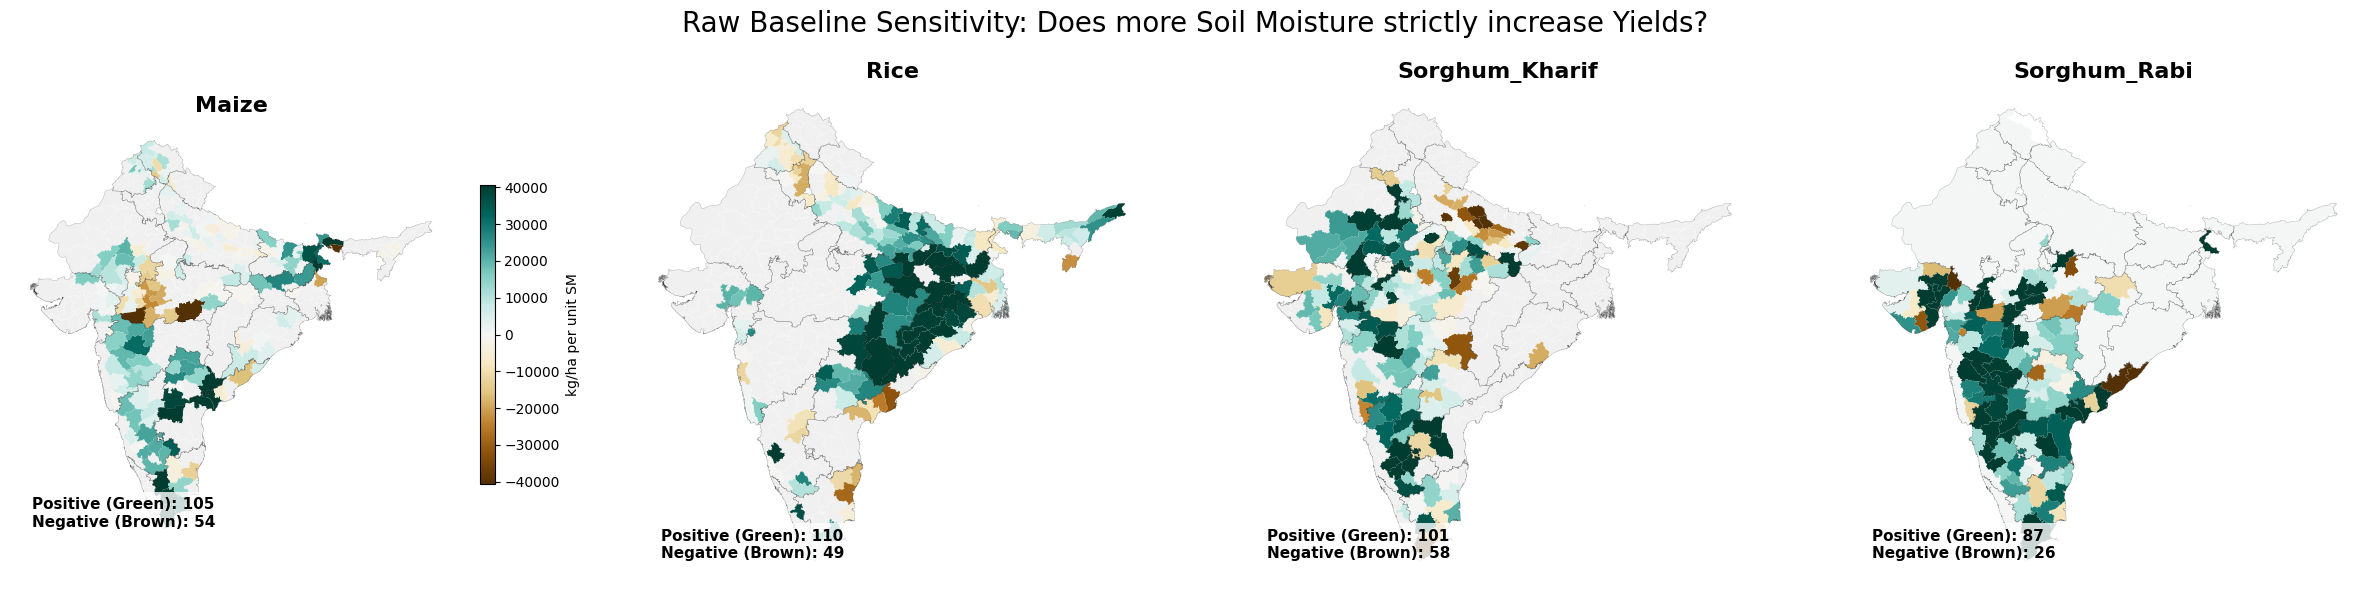

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 2: Base Linear Model (Yield ~ Trend + Soil Moisture)

print("--- Fitting Base Model: Linear Soil Moisture Sensitivities ---")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0
results_sm_linear =[]

# --- 1. Fit the Simple Model ---
for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= TARGET_SHIFT

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna(subset=['sm_season_mean', YCOL])

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values

        # Center trend to keep intercept interpretable, but keep SM completely raw
        t = (g['year'].values - g['year'].mean()).reshape(-1, 1)
        sm = g['sm_season_mean'].values.reshape(-1, 1)

        # Model: Yield ~ Trend + SM
        X = np.hstack([t, sm])
        model = LinearRegression().fit(X, y)

        results_sm_linear.append({
            'Dist Code': code,
            'crop': crop,
            'Coef_SM': model.coef_[1] # Raw sensitivity: kg/ha per unit of SM
        })

df_sm_lin = pd.DataFrame(results_sm_linear)

# --- 2. Map the Results (Top 50% Core Districts Only) ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = df_sm_lin[df_sm_lin['crop'] == crop].copy()
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # Filter to Core Zones
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    # Plot Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # Plot Foreground
    if not top_50.empty:
        # Use robust percentiles to prevent massive outliers from washing out the map colors
        limit = np.percentile(np.abs(top_50['Coef_SM'].dropna()), 90)
        limit = max(limit, 1.0) # Prevent zero division on flat data
        norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

        # We use BrBG (Brown-Blue/Green). Green/Blue means more SM = more yield. Brown means more SM = lower yield (waterlogging).
        top_50.plot(column='Coef_SM', ax=ax, cmap='BrBG', norm=norm,
                    legend=(i==0), legend_kwds={'label': 'kg/ha per unit SM', 'shrink': 0.6})

        # Tally positive vs negative responses
        pos = (top_50['Coef_SM'] > 0).sum()
        neg = (top_50['Coef_SM'] < 0).sum()

        ax.text(0.05, 0.05, f"Positive (Green): {pos}\nNegative (Brown): {neg}",
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.3, alpha=0.3)
    ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

plt.suptitle("Raw Baseline Sensitivity: Does more Soil Moisture strictly increase Yields?", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Fitting Quadratic Model: Soil Moisture 'Goldilocks' Curve ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


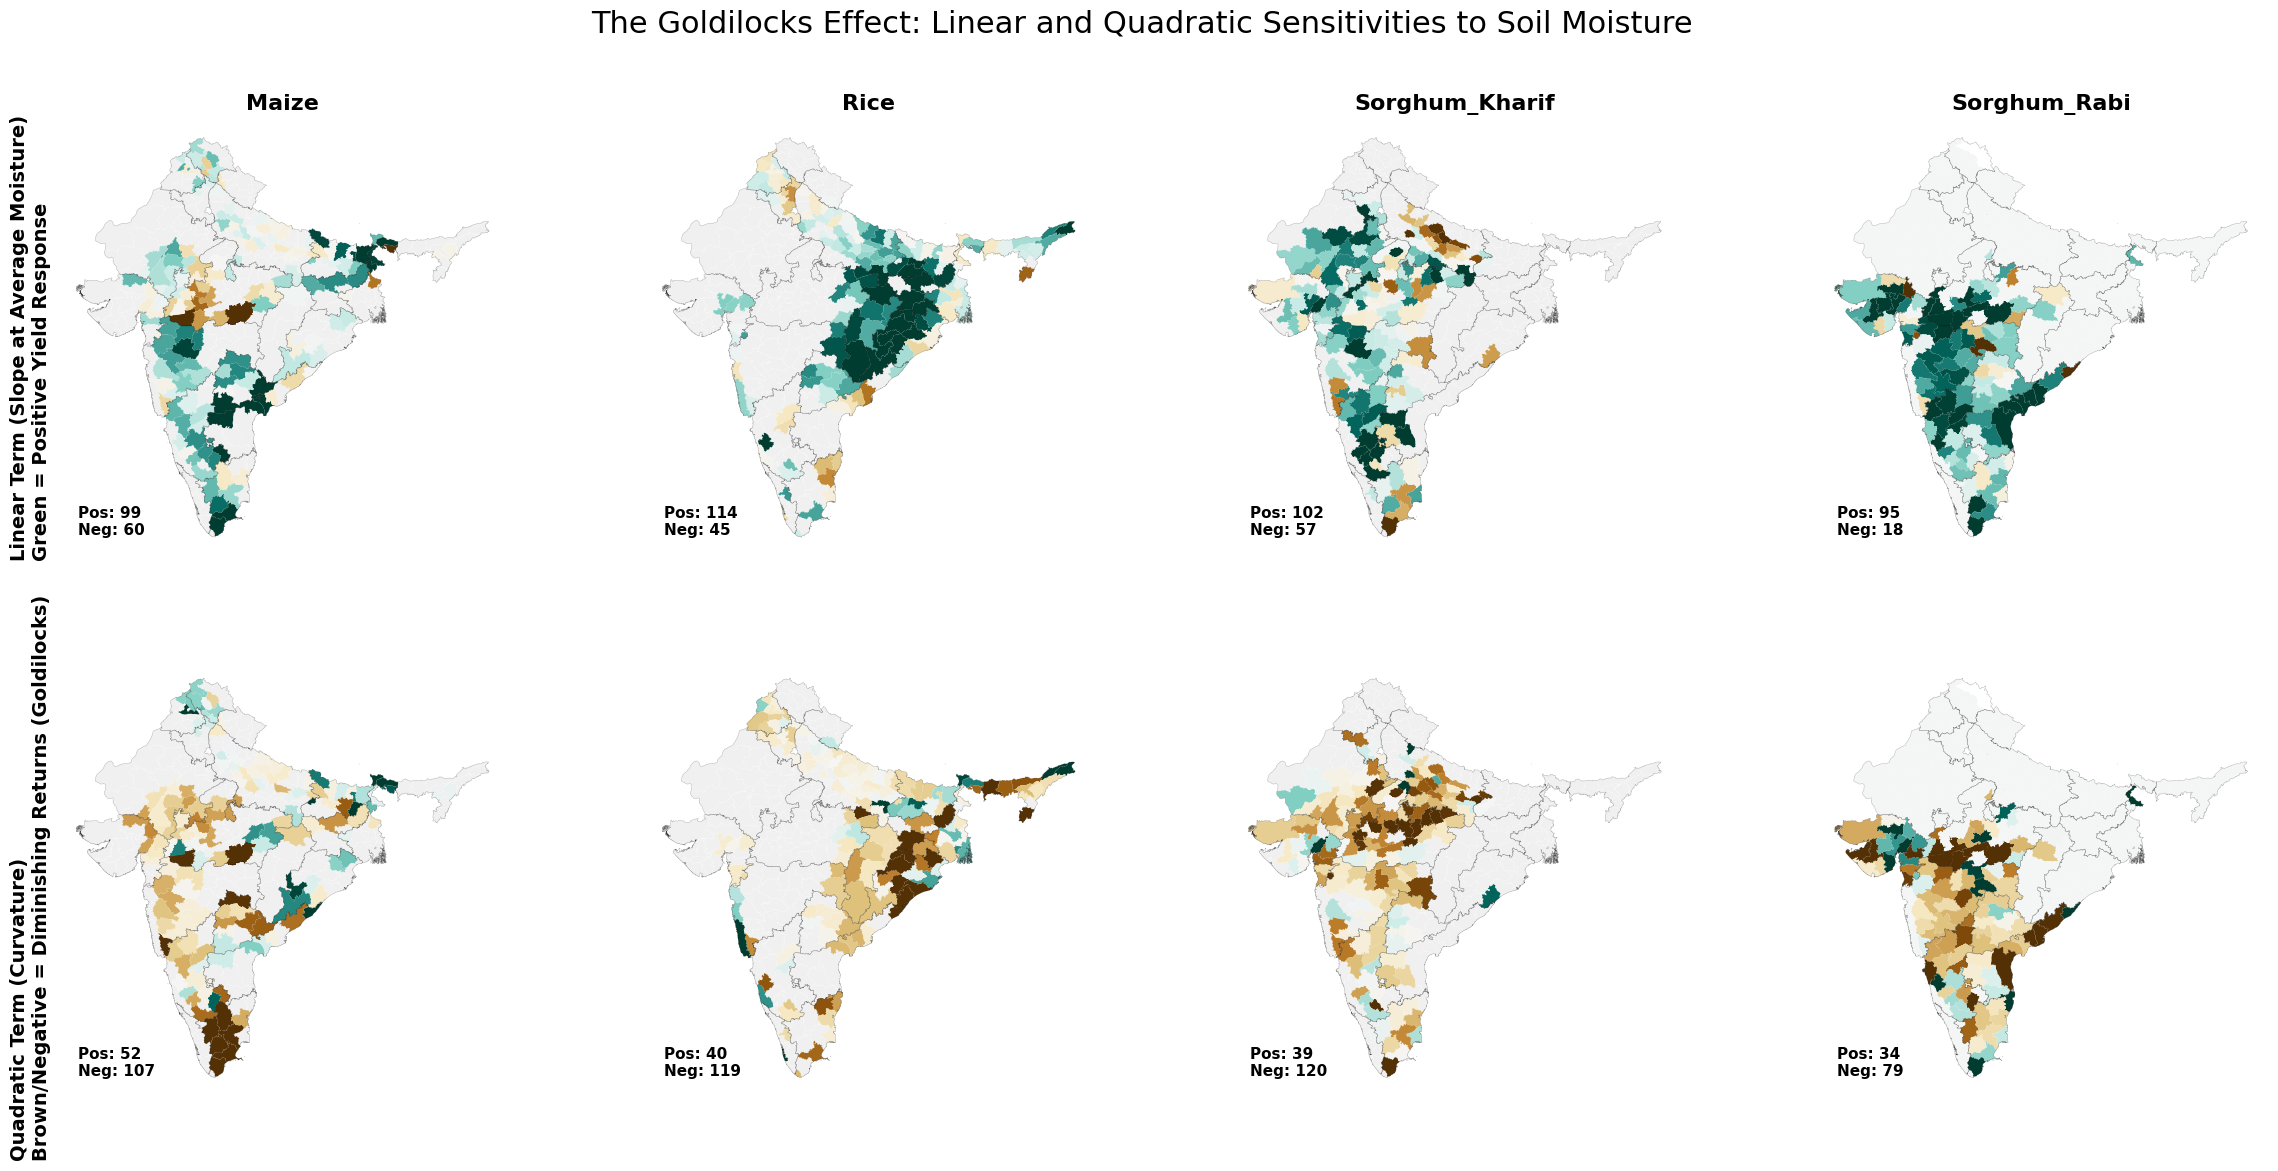

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 3: Quadratic Soil Moisture Model (Yield ~ Trend + SM + SM^2)

print("--- Fitting Quadratic Model: Soil Moisture 'Goldilocks' Curve ---")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0
results_sm_quad =[]

# --- 1. Fit the Quadratic Model ---
for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= TARGET_SHIFT

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna(subset=['sm_season_mean', YCOL])

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values

        # Trend (centered for interpretable intercept)
        t = (g['year'].values - g['year'].mean()).reshape(-1, 1)

        # CRITICAL: Center SM before squaring to avoid severe collinearity
        sm_raw = g['sm_season_mean'].values.reshape(-1, 1)
        sm_cen = sm_raw - sm_raw.mean()
        sm_sq = sm_cen ** 2

        # Model: Yield ~ Trend + SM_cen + SM_sq
        X = np.hstack([t, sm_cen, sm_sq])
        model = LinearRegression().fit(X, y)

        results_sm_quad.append({
            'Dist Code': code,
            'crop': crop,
            'Coef_SM_Lin': model.coef_[1],  # Slope at average SM
            'Coef_SM_Quad': model.coef_[2]  # Curvature (Negative = Concave/Goldilocks)
        })

df_sm_quad = pd.DataFrame(results_sm_quad)

# --- 2. Map the Results (Top 50% Core Districts Only) ---
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
terms = ['Coef_SM_Lin', 'Coef_SM_Quad']
row_titles =['Linear Term (Slope at Average Moisture)\nGreen = Positive Yield Response',
              'Quadratic Term (Curvature)\nBrown/Negative = Diminishing Returns (Goldilocks)']

for c_idx, crop in enumerate(crops):
    data = df_sm_quad[df_sm_quad['crop'] == crop].copy()
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # Filter to Core Zones
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    for r_idx, term in enumerate(terms):
        ax = axes[r_idx, c_idx]

        # Background
        if not bottom_50.empty:
            bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

        # Foreground
        if not top_50.empty:
            # Robust percentiles for color limits
            limit = np.percentile(np.abs(top_50[term].dropna()), 90)
            limit = max(limit, 0.1) # Prevent flatline errors
            norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

            # Using BrBG (Brown -> White -> Green)
            top_50.plot(column=term, ax=ax, cmap='BrBG', norm=norm)

            # Tally Counts
            pos = (top_50[term] > 0).sum()
            neg = (top_50[term] < 0).sum()

            text_color = "black"
            ax.text(0.05, 0.05, f"Pos: {pos}\nNeg: {neg}",
                    transform=ax.transAxes, fontsize=11, fontweight='bold', color=text_color,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.3, alpha=0.3)
        ax.set_axis_off()

        if r_idx == 0:
            ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
        if c_idx == 0:
            ax.text(-0.1, 0.5, row_titles[r_idx], transform=ax.transAxes,
                    rotation=90, va='center', fontsize=14, fontweight='bold')

plt.suptitle("The Goldilocks Effect: Linear and Quadratic Sensitivities to Soil Moisture", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Fitting Base Model: Linear Temperature Sensitivities ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


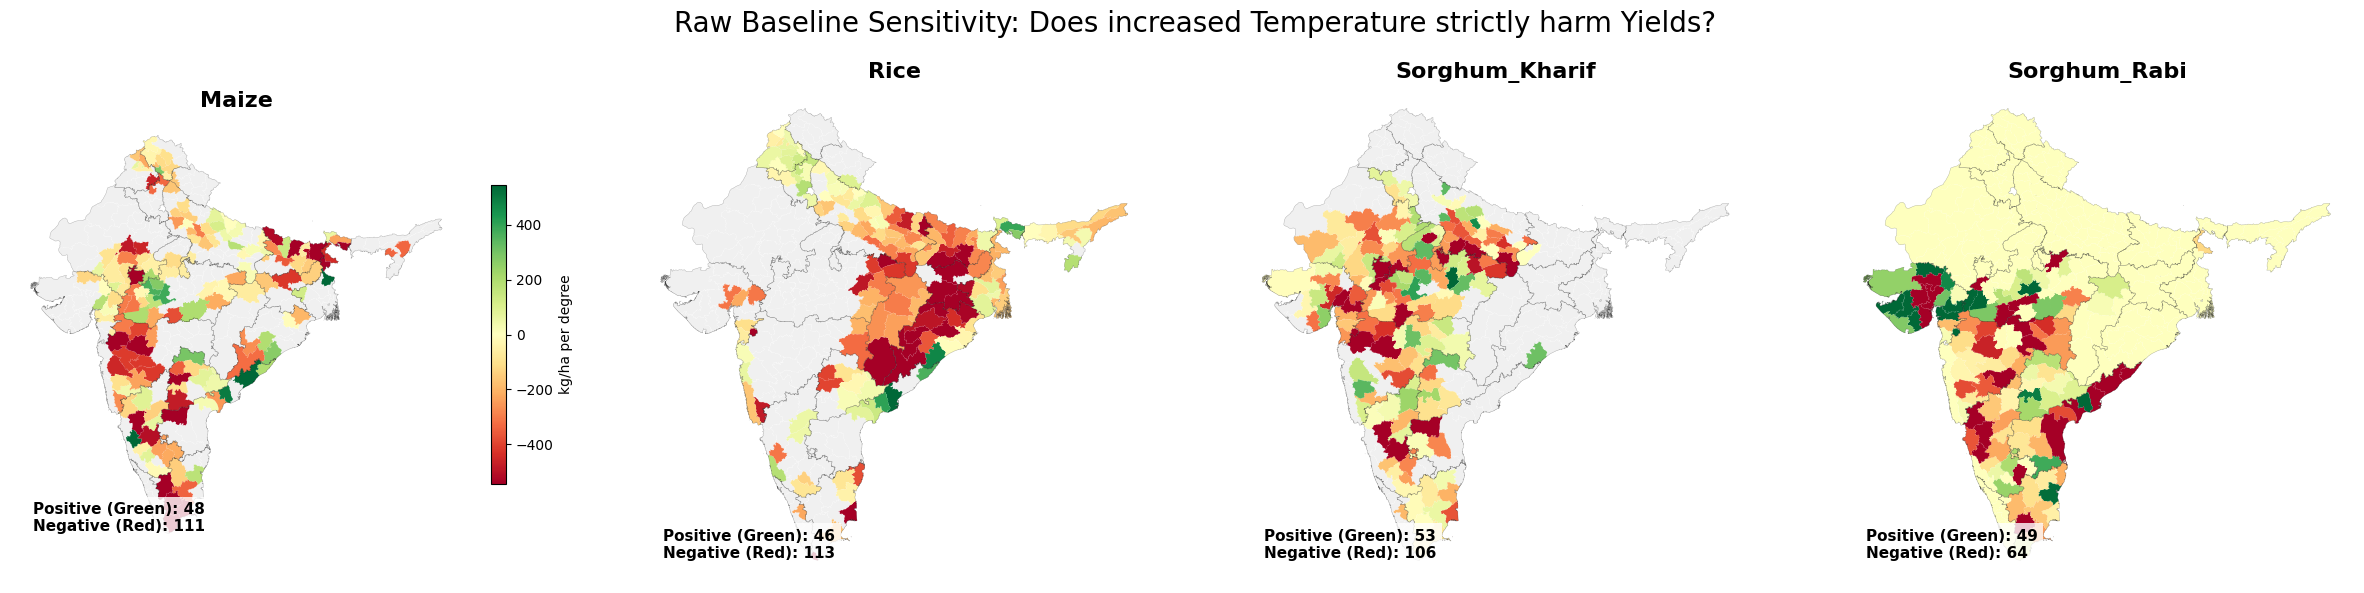

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 4: Base Linear Model (Yield ~ Trend + Temperature)

print("--- Fitting Base Model: Linear Temperature Sensitivities ---")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0
results_temp_linear =[]

# --- 1. Fit the Simple Model ---
for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= TARGET_SHIFT

    # Drop rows missing Tmax or Yield
    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna(subset=['tmax_season_mean', YCOL])

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values

        # Center trend to keep intercept interpretable, keep Tmax completely raw
        t = (g['year'].values - g['year'].mean()).reshape(-1, 1)
        tmax = g['tmax_season_mean'].values.reshape(-1, 1)

        # Model: Yield ~ Trend + Tmax
        X = np.hstack([t, tmax])
        model = LinearRegression().fit(X, y)

        results_temp_linear.append({
            'Dist Code': code,
            'crop': crop,
            'Coef_Temp': model.coef_[1] # Raw sensitivity: kg/ha per degree Celsius (or Kelvin)
        })

df_temp_lin = pd.DataFrame(results_temp_linear)

# --- 2. Map the Results (Top 50% Core Districts Only) ---
fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    ax = axes[i]
    data = df_temp_lin[df_temp_lin['crop'] == crop].copy()
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # Filter to Core Zones
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    # Plot Background
    if not bottom_50.empty:
        bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

    # Plot Foreground
    if not top_50.empty:
        # Robust percentiles to prevent extreme outliers from washing out colors
        limit = np.percentile(np.abs(top_50['Coef_Temp'].dropna()), 90)
        limit = max(limit, 1.0) # Prevent zero division

        # Diverging norm: 0 is center.
        # Negative values (heat hurts) will be Red. Positive values (heat helps) will be Green.
        norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

        top_50.plot(column='Coef_Temp', ax=ax, cmap='RdYlGn', norm=norm,
                    legend=(i==0), legend_kwds={'label': 'kg/ha per degree', 'shrink': 0.6})

        # Tally positive vs negative responses
        pos = (top_50['Coef_Temp'] > 0).sum()
        neg = (top_50['Coef_Temp'] < 0).sum()

        ax.text(0.05, 0.05, f"Positive (Green): {pos}\nNegative (Red): {neg}",
                transform=ax.transAxes, fontsize=11, fontweight='bold',
                bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

    state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.3, alpha=0.3)
    ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax.set_axis_off()

plt.suptitle("Raw Baseline Sensitivity: Does increased Temperature strictly harm Yields?", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Fitting Quadratic Model: Temperature 'Heat Cliff' ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


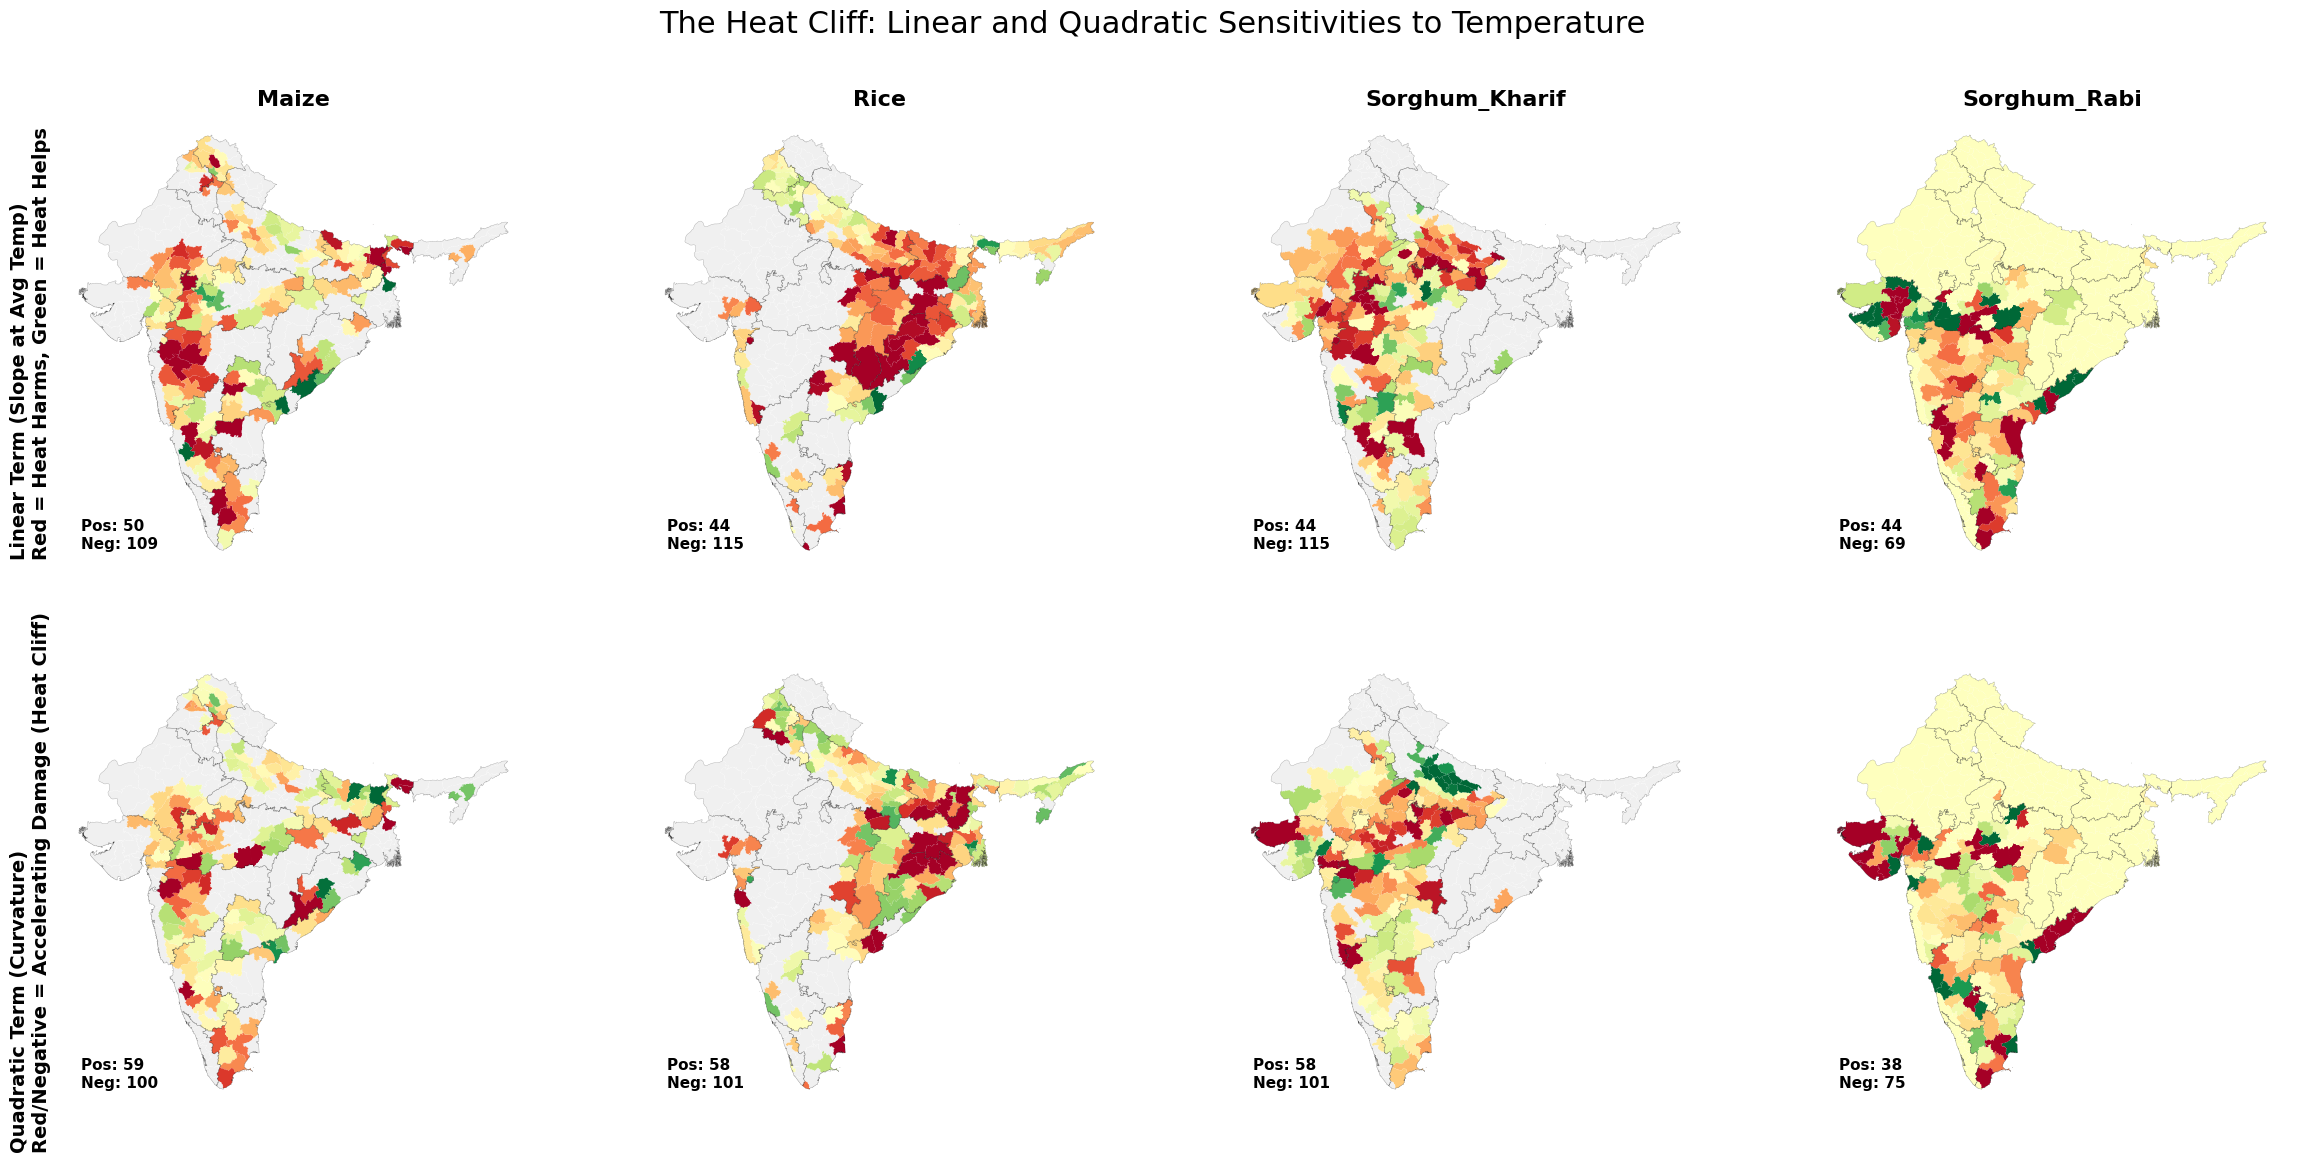

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 5: Quadratic Temperature Model (Yield ~ Trend + Tmax + Tmax^2)

print("--- Fitting Quadratic Model: Temperature 'Heat Cliff' ---")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0
results_temp_quad =[]

# --- 1. Fit the Quadratic Model ---
for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)
    yld_s = yld[yld["crop"] == crop].copy()
    yld_s['year'] -= TARGET_SHIFT

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna(subset=['tmax_season_mean', YCOL])

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values

        # Trend (centered for interpretable intercept)
        t = (g['year'].values - g['year'].mean()).reshape(-1, 1)

        # CRITICAL: Center Temp before squaring to avoid severe collinearity
        tmax_raw = g['tmax_season_mean'].values.reshape(-1, 1)
        tmax_cen = tmax_raw - tmax_raw.mean()
        tmax_sq = tmax_cen ** 2

        # Model: Yield ~ Trend + Tmax_cen + Tmax_sq
        X = np.hstack([t, tmax_cen, tmax_sq])
        model = LinearRegression().fit(X, y)

        results_temp_quad.append({
            'Dist Code': code,
            'crop': crop,
            'Coef_Temp_Lin': model.coef_[1],  # Slope at average Temp
            'Coef_Temp_Quad': model.coef_[2]  # Curvature (Negative = Heat Cliff)
        })

df_temp_quad = pd.DataFrame(results_temp_quad)

# --- 2. Map the Results (Top 50% Core Districts Only) ---
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
terms = ['Coef_Temp_Lin', 'Coef_Temp_Quad']
row_titles =['Linear Term (Slope at Avg Temp)\nRed = Heat Harms, Green = Heat Helps',
             'Quadratic Term (Curvature)\nRed/Negative = Accelerating Damage (Heat Cliff)']

for c_idx, crop in enumerate(crops):
    data = df_temp_quad[df_temp_quad['crop'] == crop].copy()
    geo_data = districts_gdf.merge(data, on='Dist Code', how='inner')

    # Filter to Core Zones
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    geo_data = geo_data.merge(cf, on='Dist Code', how='inner')
    top_50 = geo_data[geo_data['cropping_fraction'] >= threshold]
    bottom_50 = geo_data[geo_data['cropping_fraction'] < threshold]

    for r_idx, term in enumerate(terms):
        ax = axes[r_idx, c_idx]

        # Plot Background
        if not bottom_50.empty:
            bottom_50.plot(ax=ax, color='#f0f0f0', edgecolor='white', linewidth=0.1)

        # Plot Foreground
        if not top_50.empty:
            # Robust percentiles for color limits
            limit = np.percentile(np.abs(top_50[term].dropna()), 90)
            limit = max(limit, 0.1) # Prevent flatline errors
            norm = mcolors.TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

            # Using RdYlGn (Red = Negative, Green = Positive)
            # Row 1: Red = harmful heat. Row 2: Red = accelerating damage curve.
            top_50.plot(column=term, ax=ax, cmap='RdYlGn', norm=norm)

            # Tally Counts
            pos = (top_50[term] > 0).sum()
            neg = (top_50[term] < 0).sum()

            text_color = "black"
            ax.text(0.05, 0.05, f"Pos: {pos}\nNeg: {neg}",
                    transform=ax.transAxes, fontsize=11, fontweight='bold', color=text_color,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))

        state_boundaries_gdf.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=0.3, alpha=0.3)
        ax.set_axis_off()

        if r_idx == 0:
            ax.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
        if c_idx == 0:
            ax.text(-0.1, 0.5, row_titles[r_idx], transform=ax.transAxes,
                    rotation=90, va='center', fontsize=14, fontweight='bold')

plt.suptitle("The Heat Cliff: Linear and Quadratic Sensitivities to Temperature", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- Plotting Sensitivity vs. Climatology (Top 50% Core Districts) ---
    Hypothesis (Temp): Hotter districts suffer more from +1°C anomalies (Downward slope).
    Hypothesis (Water): Drier districts benefit more from +1 unit SM (Downward slope).
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


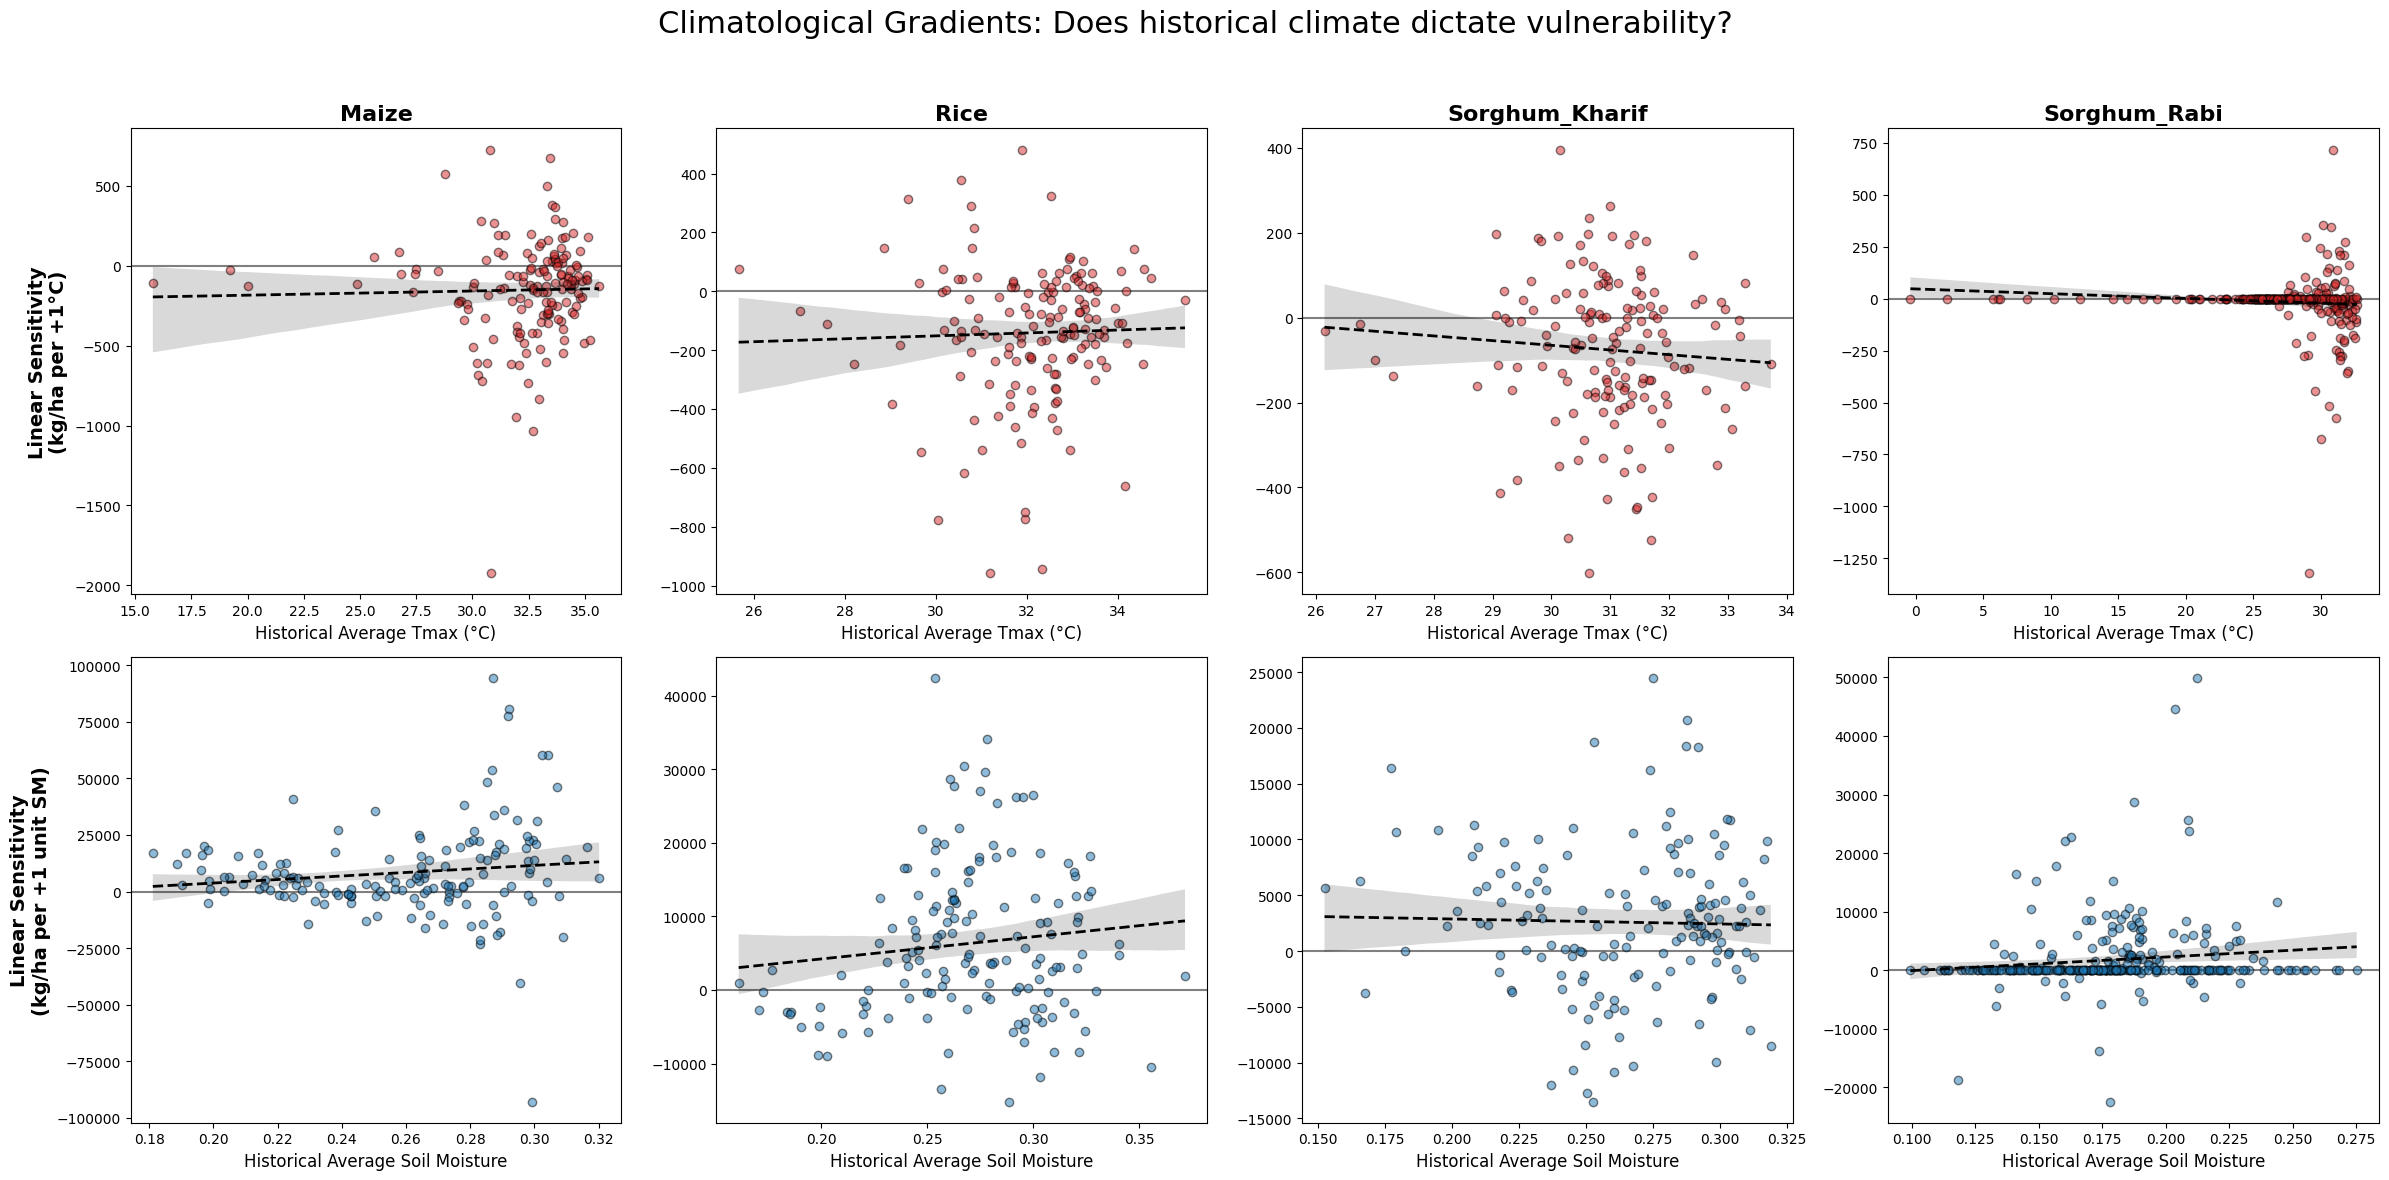

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 6: Sensitivity vs. Climatology (The Spatial Gradient)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- Plotting Sensitivity vs. Climatology (Top 50% Core Districts) ---")
print("    Hypothesis (Temp): Hotter districts suffer more from +1°C anomalies (Downward slope).")
print("    Hypothesis (Water): Drier districts benefit more from +1 unit SM (Downward slope).")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']

# --- 1. Calculate Historical Climatologies (Long-term Means) ---
climatologies = []

for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    # Get raw climate data for this crop's season
    clim = get_climate_panel_for_months_NO_WEIGHTING(months)

    # Calculate historical average for each district
    dist_means = clim.groupby('Dist Code')[['sm_season_mean', 'tmax_season_mean']].mean().reset_index()
    dist_means['crop'] = crop
    climatologies.append(dist_means)

df_clim = pd.concat(climatologies, ignore_index=True)

# --- 2. Merge Sensitivities, Climatologies, and Intensity Filters ---
# Note: This relies on df_temp_lin (Cell 4) and df_sm_lin (Cell 2) existing in memory
plot_df_temp = pd.merge(df_temp_lin, df_clim, on=['Dist Code', 'crop'], how='inner')
plot_df_sm   = pd.merge(df_sm_lin, df_clim, on=['Dist Code', 'crop'], how='inner')

fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for c_idx, crop in enumerate(crops):

    # --- Filter for Top 50% Core Production Zones ---
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    core_districts = cf[cf['cropping_fraction'] >= threshold]['Dist Code']

    # Filter DataFrames
    c_temp = plot_df_temp[(plot_df_temp['crop'] == crop) & (plot_df_temp['Dist Code'].isin(core_districts))]
    c_sm   = plot_df_sm[(plot_df_sm['crop'] == crop) & (plot_df_sm['Dist Code'].isin(core_districts))]

    # --- ROW 1: TEMPERATURE ---
    ax1 = axes[0, c_idx]

    # Scatter plot with regression line
    sns.regplot(data=c_temp, x='tmax_season_mean', y='Coef_Temp',
                ax=ax1, scatter_kws={'alpha':0.5, 'color':'#d62728', 'edgecolor':'k'},
                line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})

    # Add Zero Line (The "Harmful vs Helpful" Threshold)
    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, zorder=0)

    ax1.set_title(f"{crop.title()}", fontsize=16, fontweight='bold')
    ax1.set_xlabel("Historical Average Tmax (°C)", fontsize=12)

    if c_idx == 0:
        ax1.set_ylabel("Linear Sensitivity\n(kg/ha per +1°C)", fontsize=14, fontweight='bold')
    else:
        ax1.set_ylabel("")

    # --- ROW 2: SOIL MOISTURE ---
    ax2 = axes[1, c_idx]

    # Scatter plot with regression line
    sns.regplot(data=c_sm, x='sm_season_mean', y='Coef_SM',
                ax=ax2, scatter_kws={'alpha':0.5, 'color':'#1f77b4', 'edgecolor':'k'},
                line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})

    # Add Zero Line
    ax2.axhline(0, color='gray', linestyle='-', linewidth=1.5, zorder=0)

    ax2.set_xlabel("Historical Average Soil Moisture", fontsize=12)

    if c_idx == 0:
        ax2.set_ylabel("Linear Sensitivity\n(kg/ha per +1 unit SM)", fontsize=14, fontweight='bold')
    else:
        ax2.set_ylabel("")

plt.suptitle("Climatological Gradients: Does historical climate dictate vulnerability?", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

--- DIAGNOSTIC V2: Hunting for True Fabricated Yields ---
    Applying strict yield > 1.0 filter before counting valid years.


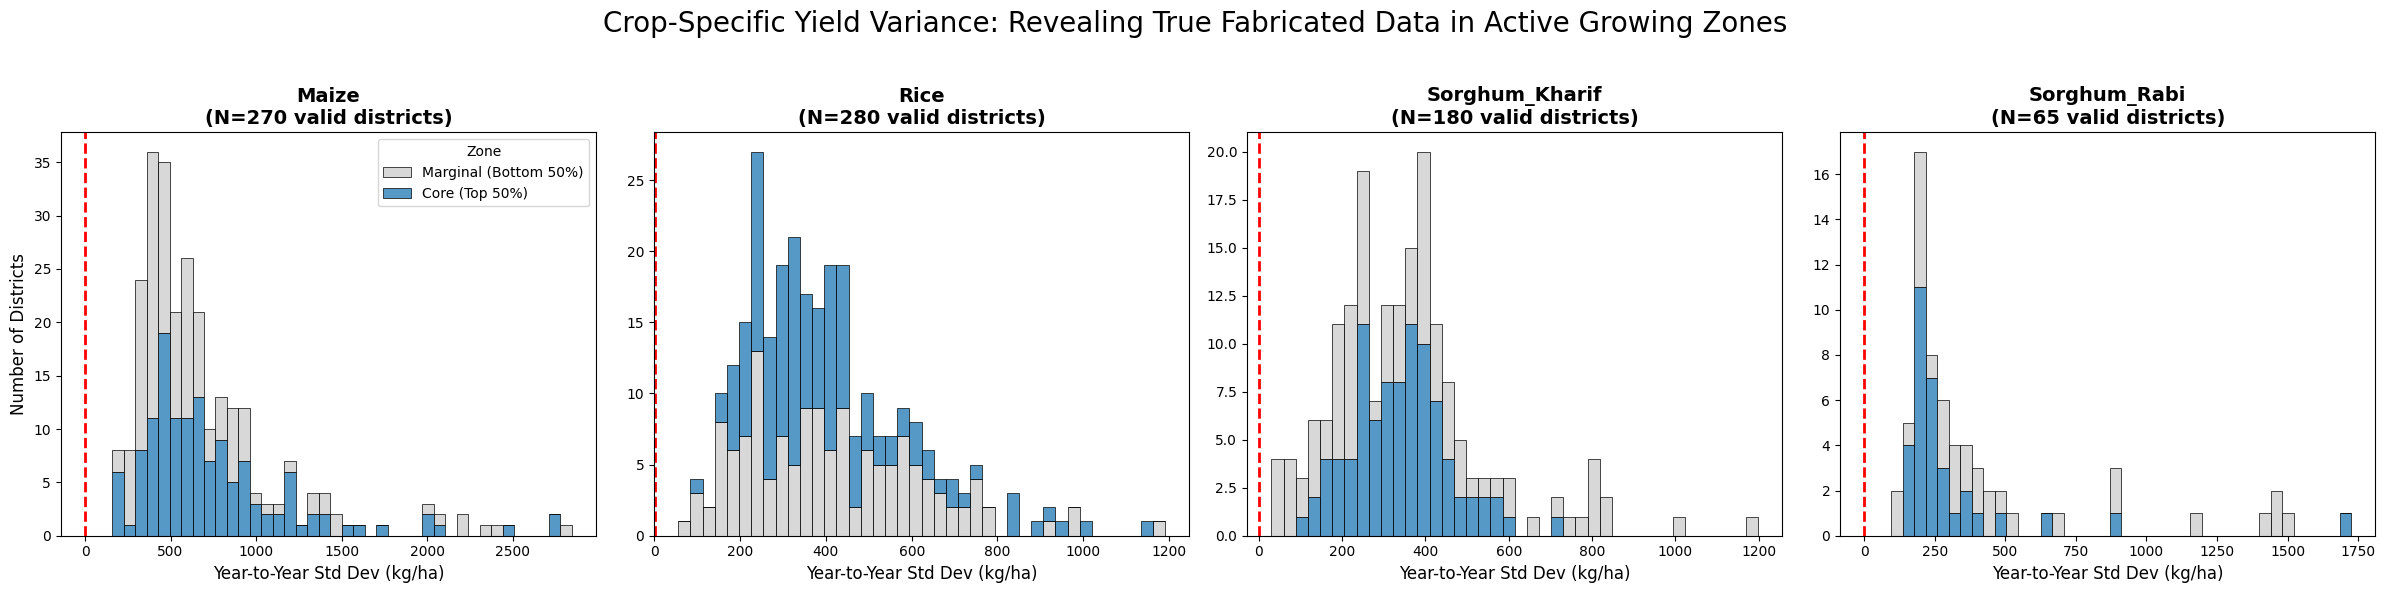


--- Crop-Specific Zombie Data Report ---


,Crop,Valid Districts (>=15 yrs),Zombie Districts (Flatline),% Fabricated Data,Zombies in Top 50% Core
0,Maize,270,0,0.0%,0
1,Rice,280,0,0.0%,0
2,Sorghum_Kharif,180,0,0.0%,0
3,Sorghum_Rabi,65,0,0.0%,0


In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 7: Diagnosing Zero-Variance Yield Reports (Corrected Footprints)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("--- DIAGNOSTIC V2: Hunting for True Fabricated Yields ---")
print("    Applying strict yield > 1.0 filter before counting valid years.")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
summary_data =[]

fig, axes = plt.subplots(1, 4, figsize=(24, 6))

for i, crop in enumerate(crops):
    # 1. Isolate crop AND explicitly drop zero-yields (just like Notebook 0)
    c_yld = yld[(yld['crop'] == crop) & (yld['yield_kg_per_ha'] > 1.0)].copy()

    # 2. Calculate stats on ACTUAL growing years
    stats = c_yld.groupby('Dist Code')['yield_kg_per_ha'].agg(
        years='count',
        yield_std='std',
        yield_mean='mean'
    ).reset_index()

    # 3. Filter to our standard >= 15 valid years threshold
    stats = stats[stats['years'] >= 15].copy()

    # 4. Merge with Cropping Fraction to check Core vs Marginal status
    cf = get_cropping_fraction(crop)
    stats = stats.merge(cf, on='Dist Code', how='inner')

    # Define Core 50% specific to THIS crop's true distribution
    threshold = cf['cropping_fraction'].quantile(0.5)
    stats['Zone'] = np.where(stats['cropping_fraction'] >= threshold, 'Core (Top 50%)', 'Marginal (Bottom 50%)')

    # 5. Identify True Zombies (Standard Deviation near 0 despite >0 yield)
    # We use < 1.0 kg/ha to catch districts carrying forward identical numbers
    stats['is_zombie'] = stats['yield_std'] < 1.0

    # 6. Compile crop-specific statistics
    total_valid = len(stats)
    zombies_total = stats['is_zombie'].sum()
    zombies_in_core = stats[(stats['Zone'] == 'Core (Top 50%)') & stats['is_zombie']].shape[0]

    summary_data.append({
        'Crop': crop.title(),
        'Valid Districts (>=15 yrs)': total_valid,
        'Zombie Districts (Flatline)': zombies_total,
        '% Fabricated Data': (zombies_total / total_valid) * 100 if total_valid > 0 else 0,
        'Zombies in Top 50% Core': zombies_in_core
    })

    # 7. Plot the distribution
    ax = axes[i]
    if total_valid > 0:
        sns.histplot(data=stats, x='yield_std', hue='Zone', multiple='stack',
                     bins=40, ax=ax, palette={'Core (Top 50%)': '#1f77b4', 'Marginal (Bottom 50%)': '#cccccc'},
                     edgecolor='k', linewidth=0.5)

    # The Red Flag line
    ax.axvline(1.0, color='red', linestyle='--', linewidth=2)

    ax.set_title(f"{crop.title()}\n(N={total_valid} valid districts)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Year-to-Year Std Dev (kg/ha)", fontsize=12)

    if i == 0:
        ax.set_ylabel("Number of Districts", fontsize=12)
    else:
        ax.set_ylabel("")
        if ax.get_legend():
            ax.get_legend().remove()

plt.suptitle("Crop-Specific Yield Variance: Revealing True Fabricated Data in Active Growing Zones", fontsize=20, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Display the rigorous summary
summary_df = pd.DataFrame(summary_data)
print("\n--- Crop-Specific Zombie Data Report ---")
display(summary_df.style.format({'% Fabricated Data': '{:.1f}%'}))

--- Recalculating Sensitivities (Strict Filters & Relative %) ---
--- Running Climate Aggregation (Smart Season: [5, 6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [6, 7, 8, 9, 10, 11]) ---
--- Running Climate Aggregation (Smart Season: [7, 8, 9, 10, 11, 12]) ---
--- Running Climate Aggregation (Smart Season: [11, 12, 1, 2, 3]) ---
    [!] Detected Year-Crossing Season (Start: 11). adjusting logic...


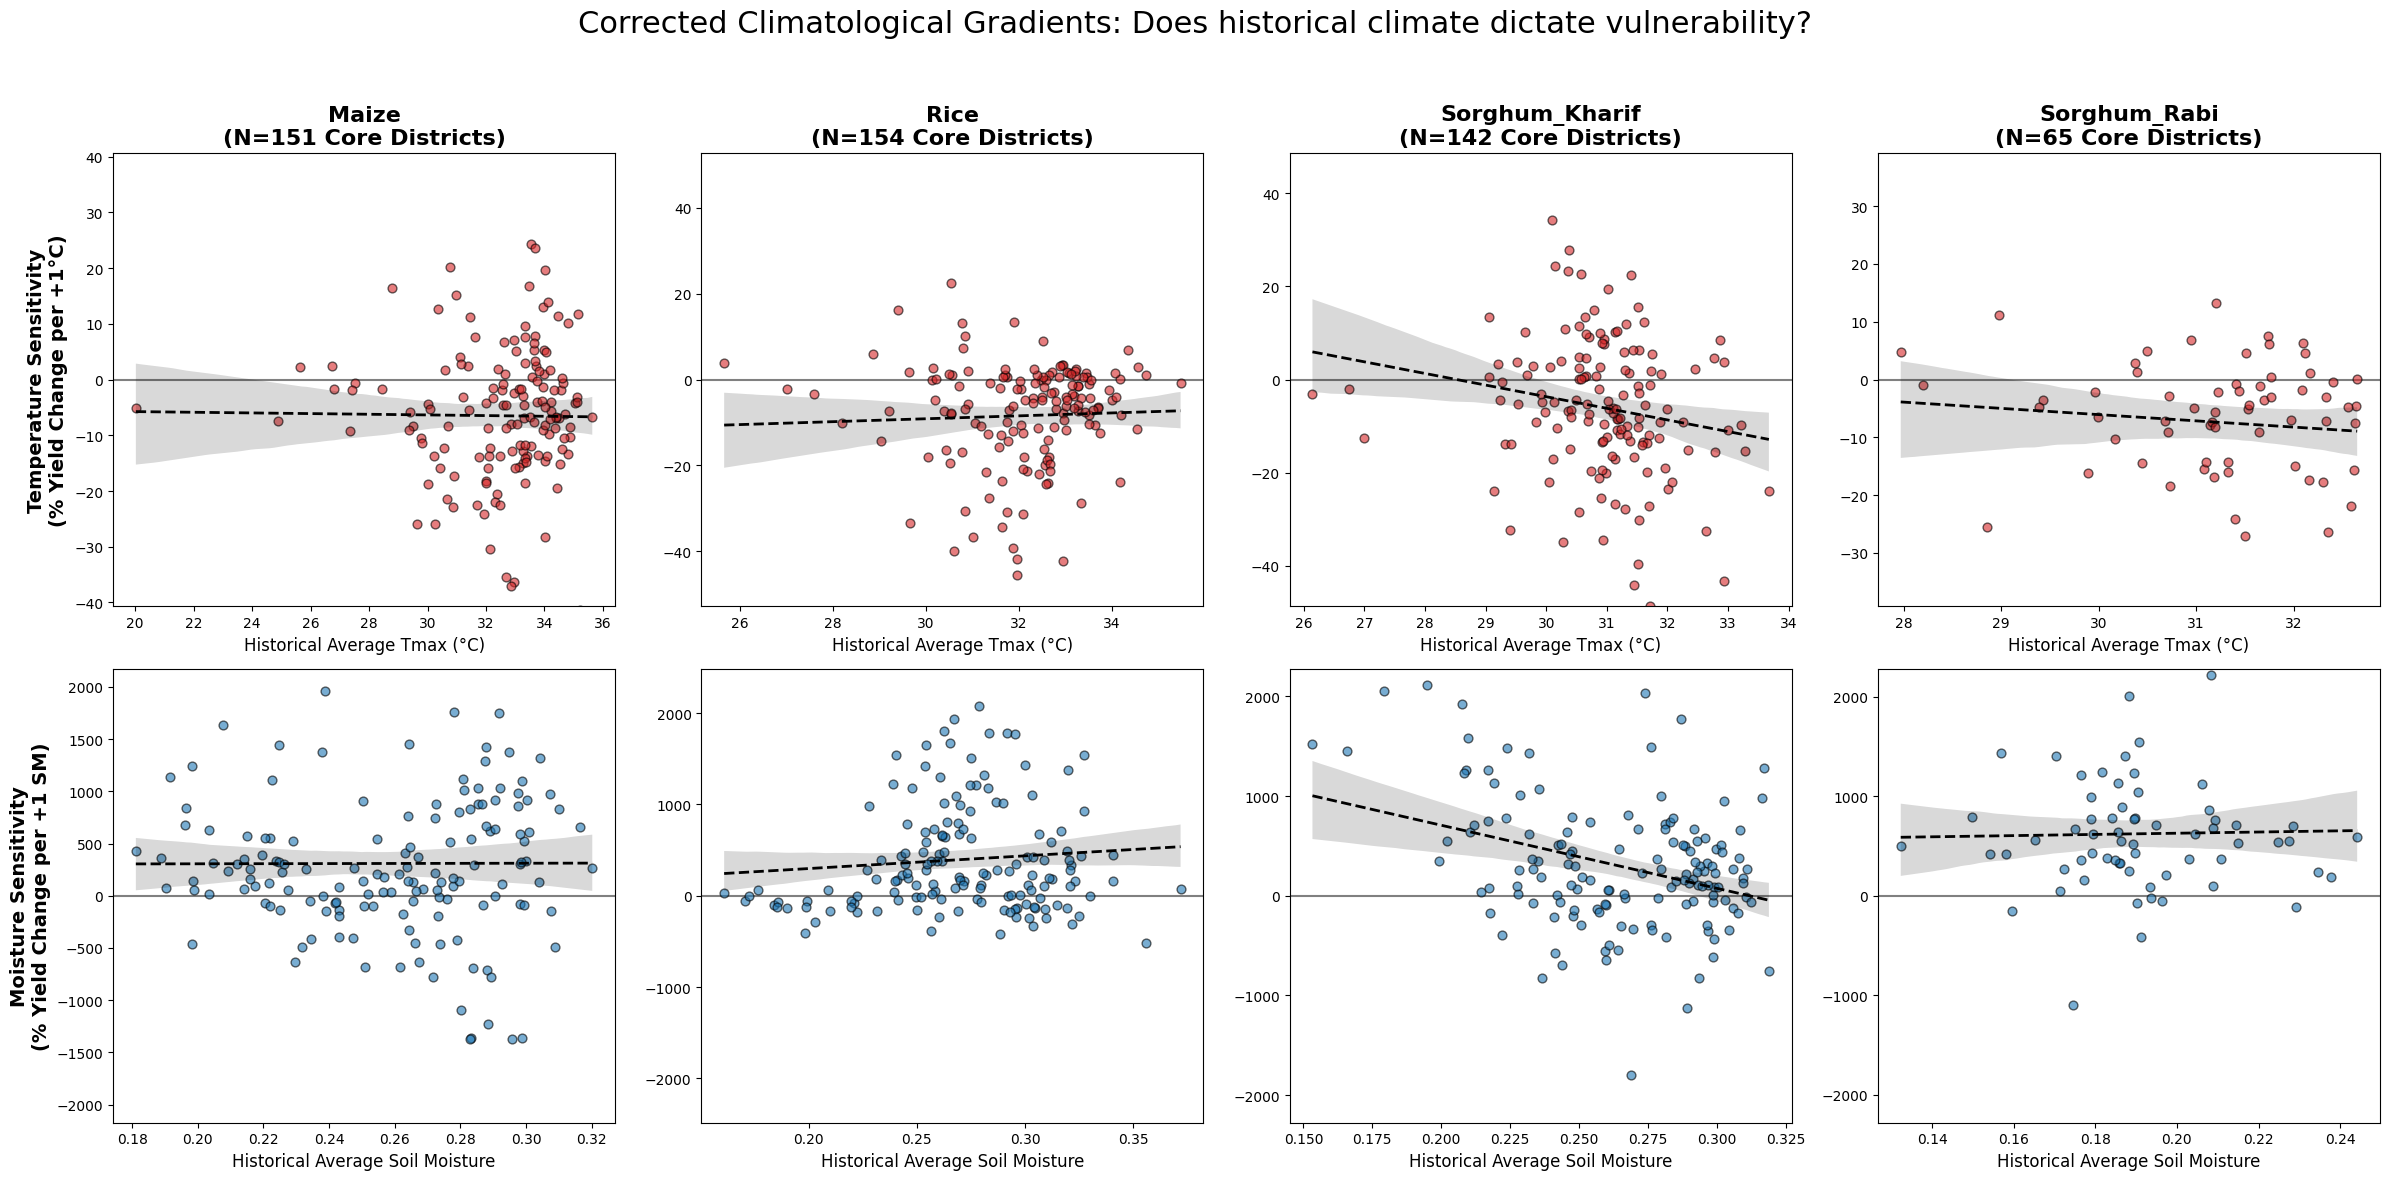

In [ ]:
# FILE: 06_Driver_Sensitivities.ipynb
# CELL 8: Corrected Sensitivity vs. Climatology (Filtered & Relative %)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

print("--- Recalculating Sensitivities (Strict Filters & Relative %) ---")

crops =['maize', 'rice', 'sorghum_kharif', 'sorghum_rabi']
TARGET_SHIFT = 0
results_list =[]

# --- 1. Safely Calculate Sensitivities ---
for crop in crops:
    calendar = CROP_CALENDARS[crop]
    months = get_month_range(get_middle_month(calendar['planting_start'], calendar['planting_end']),
                             get_middle_month(calendar['harvest_start'], calendar['harvest_end']))

    clim = get_climate_panel_for_months_NO_WEIGHTING(months)

    # STRICT FILTER: Drop zeroes upfront just like in the main hierarchical model
    yld_s = yld[(yld["crop"] == crop) & (yld[YCOL] > 1.0)].copy()
    yld_s['year'] -= TARGET_SHIFT

    df = pd.merge(clim, yld_s, on=["Dist Code", "year"]).dropna(subset=['sm_season_mean', 'tmax_season_mean', YCOL])

    for code, g in df.groupby('Dist Code'):
        if len(g) < 15: continue

        y = g[YCOL].values
        mean_y = y.mean()

        # Center trend
        t = (g['year'].values - g['year'].mean()).reshape(-1, 1)
        sm = g['sm_season_mean'].values.reshape(-1, 1)
        tmax = g['tmax_season_mean'].values.reshape(-1, 1)

        # Linear SM Model
        m_sm = LinearRegression().fit(np.hstack([t, sm]), y)
        coef_sm = m_sm.coef_[1]

        # Linear Temp Model
        m_temp = LinearRegression().fit(np.hstack([t, tmax]), y)
        coef_temp = m_temp.coef_[1]

        # RELATIVE SENSITIVITY: (% change in yield per unit of weather)
        rel_sm = (coef_sm / mean_y) * 100
        rel_temp = (coef_temp / mean_y) * 100

        results_list.append({
            'Dist Code': code,
            'crop': crop,
            'Historical_SM': g['sm_season_mean'].mean(),
            'Historical_Temp': g['tmax_season_mean'].mean(),
            'Rel_SM_Sens': rel_sm,
            'Rel_Temp_Sens': rel_temp
        })

df_clean = pd.DataFrame(results_list)

# --- 2. Plotting ---
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

for c_idx, crop in enumerate(crops):

    # Get Core Districts for this specific crop
    cf = get_cropping_fraction(crop)
    threshold = cf['cropping_fraction'].quantile(0.5)
    core_districts = cf[cf['cropping_fraction'] >= threshold]['Dist Code']

    # Filter data to Core Zones + Remove Himalayan/Artifact Temp Outliers (< 20°C)
    plot_data = df_clean[(df_clean['crop'] == crop) &
                         (df_clean['Dist Code'].isin(core_districts)) &
                         (df_clean['Historical_Temp'] > 20)].copy()

    # --- ROW 1: TEMPERATURE ---
    ax1 = axes[0, c_idx]
    sns.regplot(data=plot_data, x='Historical_Temp', y='Rel_Temp_Sens',
                ax=ax1, scatter_kws={'alpha':0.6, 'color':'#d62728', 'edgecolor':'k', 's':40},
                line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})

    ax1.axhline(0, color='gray', linestyle='-', linewidth=1.5, zorder=0)
    ax1.set_title(f"{crop.title()}\n(N={len(plot_data)} Core Districts)", fontsize=16, fontweight='bold')
    ax1.set_xlabel("Historical Average Tmax (°C)", fontsize=12)

    # Cap extreme Y-axis blowouts for readability
    ylim = np.percentile(np.abs(plot_data['Rel_Temp_Sens']), 95) * 1.5
    ax1.set_ylim(-ylim, ylim)

    if c_idx == 0:
        ax1.set_ylabel("Temperature Sensitivity\n(% Yield Change per +1°C)", fontsize=14, fontweight='bold')
    else: ax1.set_ylabel("")

    # --- ROW 2: SOIL MOISTURE ---
    ax2 = axes[1, c_idx]
    sns.regplot(data=plot_data, x='Historical_SM', y='Rel_SM_Sens',
                ax=ax2, scatter_kws={'alpha':0.6, 'color':'#1f77b4', 'edgecolor':'k', 's':40},
                line_kws={'color':'black', 'linewidth':2, 'linestyle':'--'})

    ax2.axhline(0, color='gray', linestyle='-', linewidth=1.5, zorder=0)
    ax2.set_xlabel("Historical Average Soil Moisture", fontsize=12)

    ylim_sm = np.percentile(np.abs(plot_data['Rel_SM_Sens']), 95) * 1.5
    ax2.set_ylim(-ylim_sm, ylim_sm)

    if c_idx == 0:
        ax2.set_ylabel("Moisture Sensitivity\n(% Yield Change per +1 SM)", fontsize=14, fontweight='bold')
    else: ax2.set_ylabel("")

plt.suptitle("Corrected Climatological Gradients: Does historical climate dictate vulnerability?", fontsize=22, y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()